# Məlumatın vizuallaşdırılması üçün Seaborn kitabxanası:
## Kəşfiyyat xarakterli analiz (EDA) Modulu

**Məqsəd:** Bu ev tapşırığı sizin `Seaborn` kitabxanasının müxtəlif vizualizasiya funksiyalarını konseptual və texniki səviyyədə mənimsəməsi üçün tərtib edilmişdir. Tapşırıqlar əlaqə (relational), paylanma (distribution), kateqorik (categorical) qrafiklərdən tutmuş çoxpanelli (multi-plot) şəbəkələrə qədər bütün əsas modul və funksiyaları əhatə edir.

### Bölmə 1: Təməl installing və datanın yüklənməsi

In [1]:
# 1. Seaborn (sns), Matplotlib.pyplot (plt) və Pandas (pd) kitabxanalarını idxal edin.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 2. Seaborn-un vizual mövzusunu (theme) 'whitegrid', kontekstini 'notebook', palitrasını isə 'muted' olaraq təyin edin.
sns.set_theme(context="notebook", style="whitegrid", palette="muted", font="arial")

In [3]:
# 3. Seaborn daxilindəki 'tips' (bəxşişlər) məlumat dəstini `sns.load_dataset()` vasitəsilə 'df' dəyişəninə yükləyin.
df=sns.load_dataset("tips")

In [4]:
# 4. Məlumat dəstinin strukturunu anlamaq üçün ilk 5 sətri (head) və ümumi məlumatları (info) ekrana çıxarın.
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


### Bölmə 2: Əlaqə qrafikləri (Relational Plots - relplot, scatterplot, lineplot)

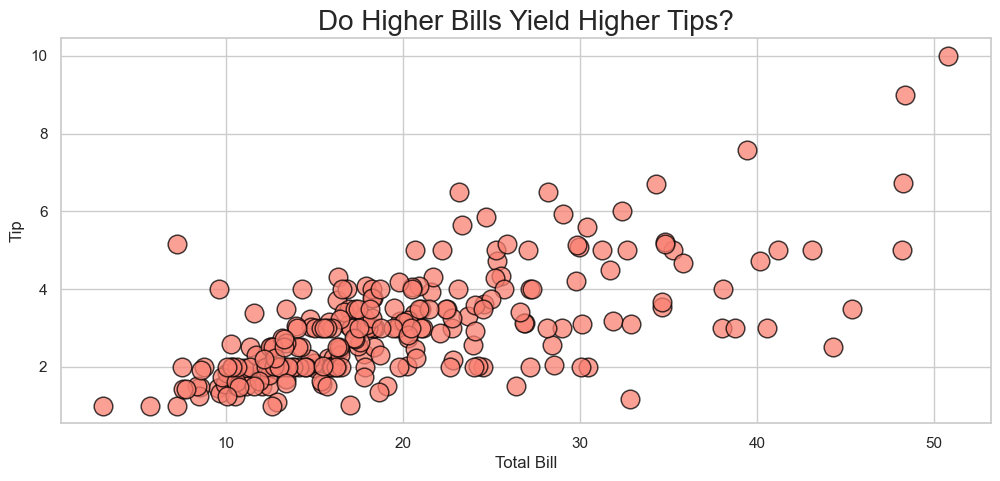

In [22]:
# 5. 'total_bill' (X oxu) və 'tip' (Y oxu) arasındakı asılılığı göstərən sadə bir səpilmə qrafiki (scatterplot) qurun.
plt.figure(figsize=(12, 5))
sns.scatterplot(data=df, x="total_bill", y="tip", marker="o", color="salmon", s=180, edgecolor="black", alpha=0.75)
plt.title("Do Higher Bills Yield Higher Tips?", fontsize=20)
plt.ylabel("Tip")
plt.xlabel("Total Bill");

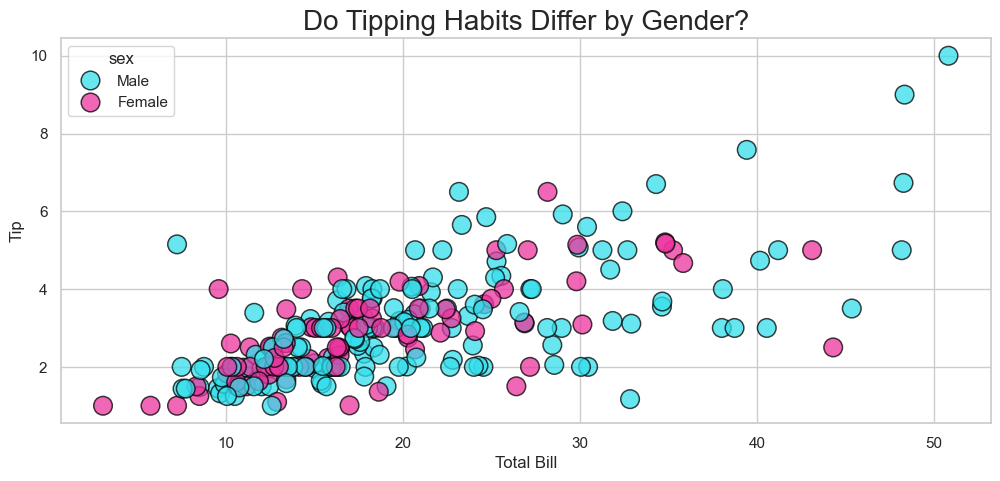

In [23]:
# 6. Eyni səpilmə qrafikini qurun, lakin bu dəfə nöqtələrin rəngini (hue) müştərinin cinsiyyətinə ('sex') görə fərqləndirin.
plt.figure(figsize=(12, 5))
sns.scatterplot(data=df, x="total_bill", y="tip", hue="sex", marker="o", palette=["#34deeb", "#eb349e"], s=180, edgecolor="black", alpha=0.75)
plt.title("Do Tipping Habits Differ by Gender?", fontsize=20)
plt.ylabel("Tip")
plt.xlabel("Total Bill");

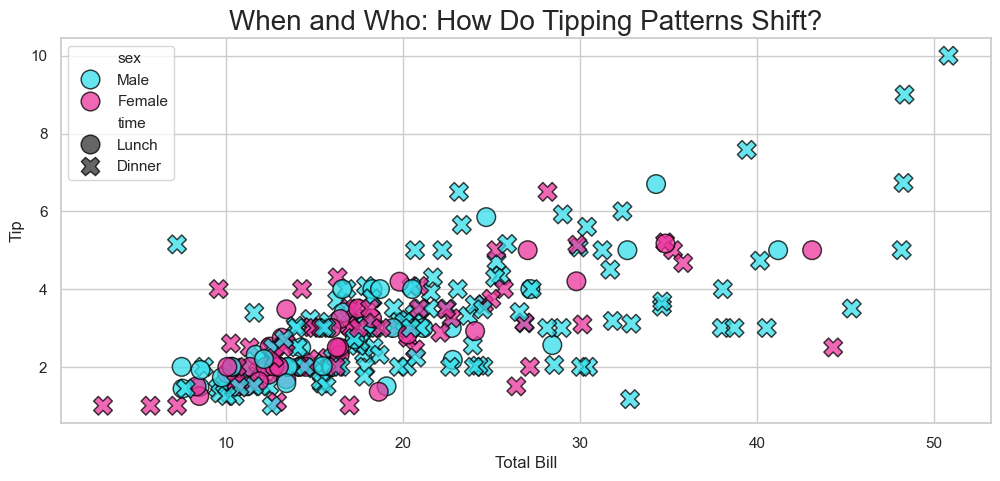

In [25]:
# 7. Əvvəlki qrafikə 'time' (nahar/şam) dəyişənini nöqtələrin forması (style) olaraq əlavə edin.
plt.figure(figsize=(12, 5))
sns.scatterplot(data=df, x="total_bill", y="tip", hue="sex", style="time", palette=["#34deeb", "#eb349e"], s=180, edgecolor="black", alpha=0.75)
plt.title("When and Who: How Do Tipping Patterns Shift?", fontsize=20)
plt.ylabel("Tip")
plt.xlabel("Total Bill");

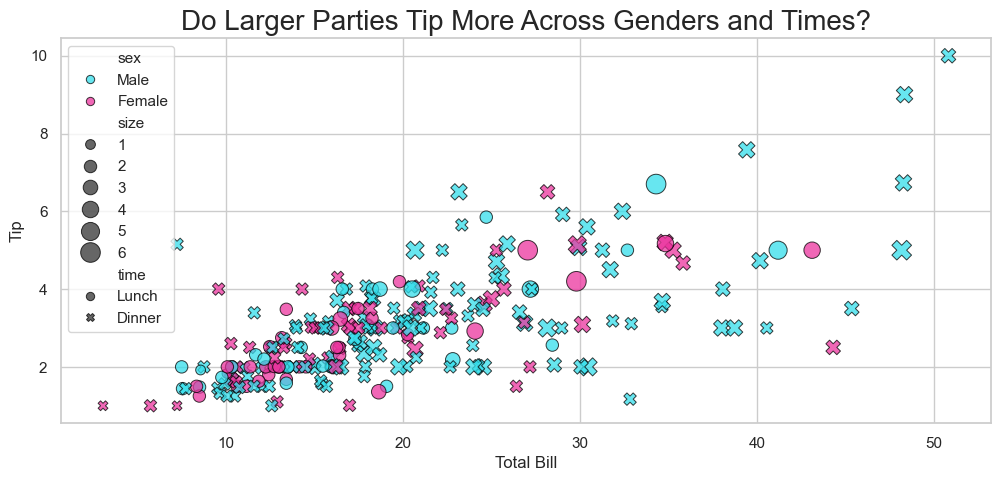

In [30]:
# 8. Nöqtələrin ölçüsünü (size) masadakı adam sayına ('size' sütunu) görə dəyişən formaya salın.
plt.figure(figsize=(12, 5))
sns.scatterplot(data=df, x="total_bill", y="tip", hue="sex", style="time", size="size", palette=["#34deeb", "#eb349e"], sizes=(50, 200), edgecolor="black", alpha=0.75)
plt.title("Do Larger Parties Tip More Across Genders and Times?", fontsize=20)
plt.ylabel("Tip")
plt.xlabel("Total Bill");

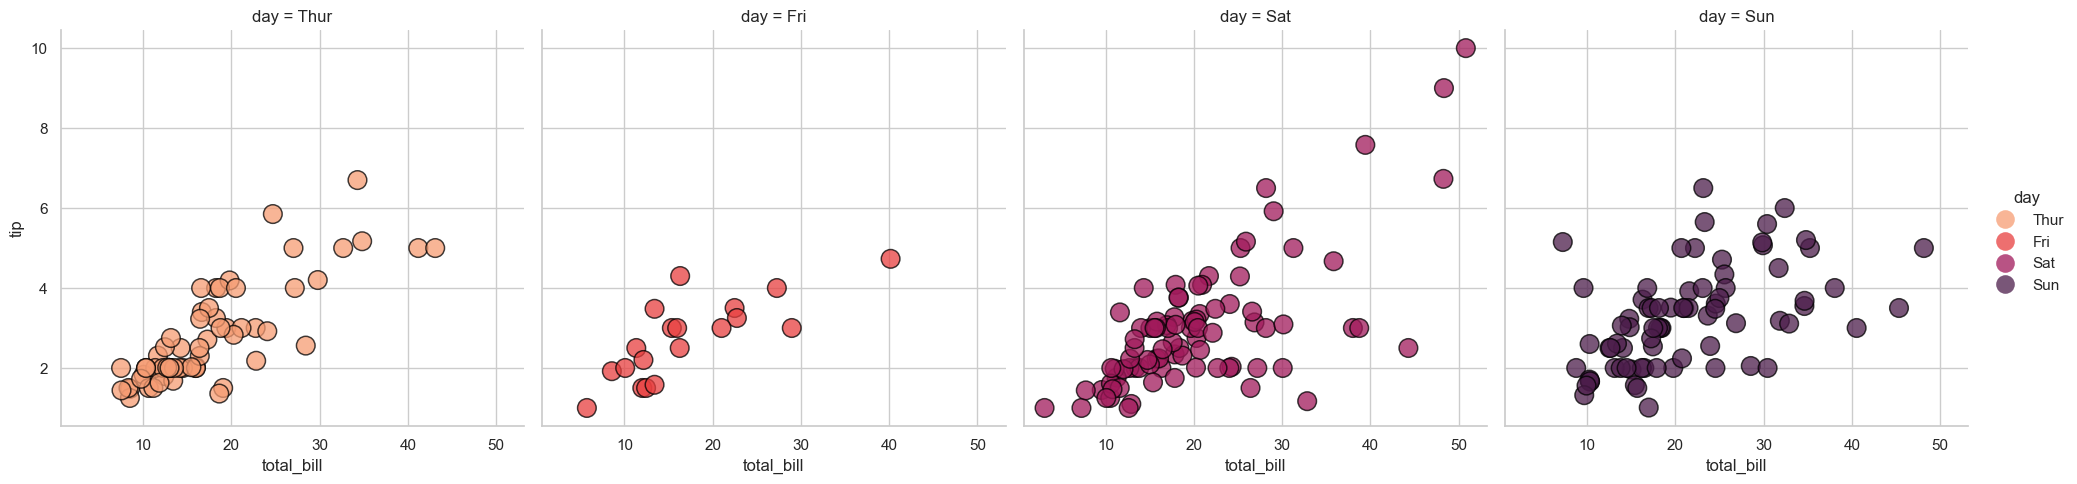

In [39]:
# 9. `relplot` funksiyasından istifadə edərək 'total_bill' və 'tip' arasındakı asılılığı göstərin, lakin qrafikləri günlərə ('day') görə fərqli sütunlarda (col) ayırın.
sns.relplot(data=df, x="total_bill", y="tip", col="day", hue="day", palette="rocket_r", edgecolor="black", alpha=0.75, s=180);

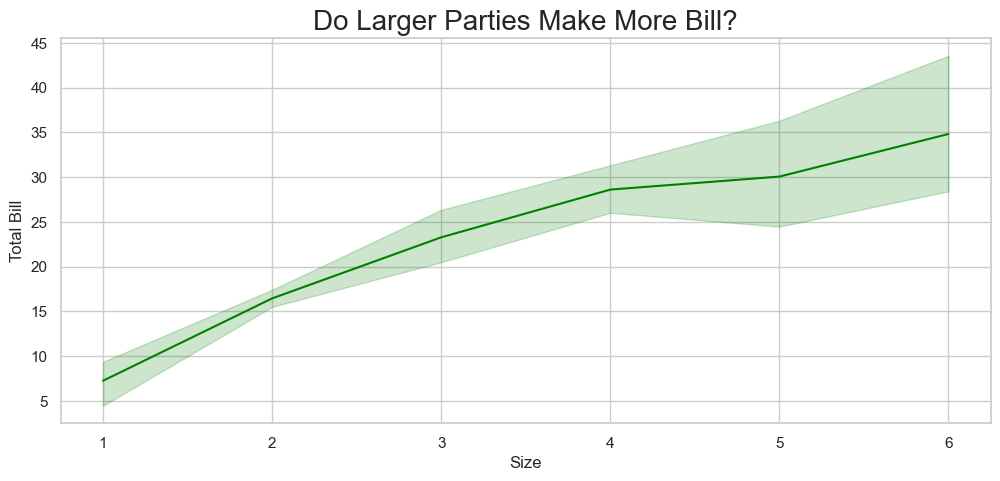

In [51]:
# 10. `lineplot` vasitəsilə masanın ölçüsü ('size') artdıqca hesabın ('total_bill') necə dəyişdiyini (orta dəyər və etibarlılıq intervalı ilə) vizuallaşdırın.
plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x="size", y="total_bill", color="green", estimator="mean", errorbar=("ci", 95))
plt.title("Do Larger Parties Make More Bill?", fontsize=20)
plt.xlabel("Size")
plt.ylabel("Total Bill");

### Bölmə 3: Paylanma qrafikləri (Distribution Plots - histplot, kdeplot, displot)

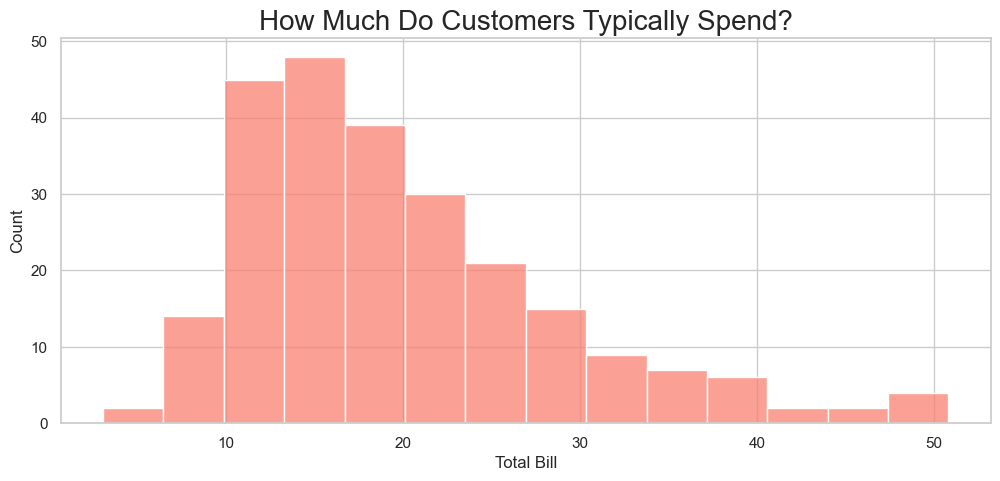

In [58]:
# 11. Yalnız 'total_bill' dəyişəni üçün histoqram (histplot) qurun.
plt.figure(figsize=(12, 5))
sns.histplot(data=df, x="total_bill", stat="count", color="salmon")
plt.title("How Much Do Customers Typically Spend?", fontsize=20)
plt.ylabel("Count")
plt.xlabel("Total Bill");

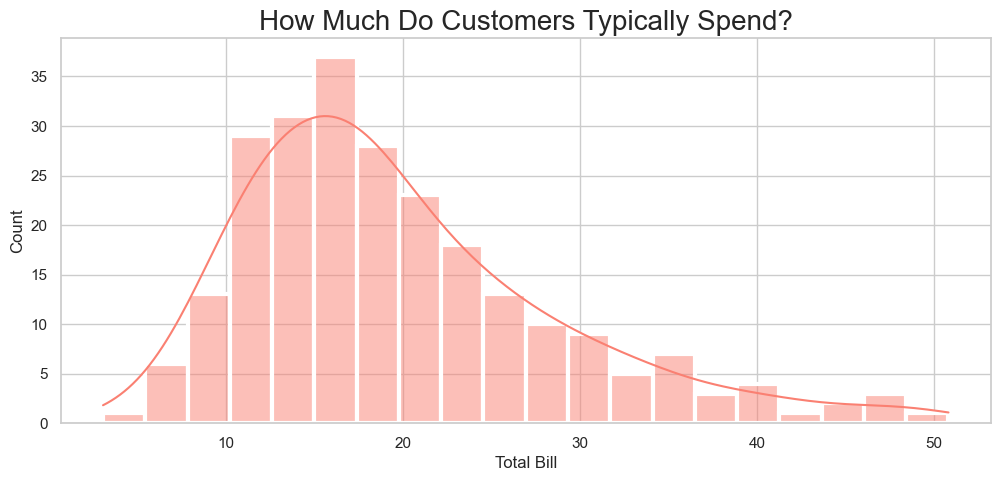

In [63]:
# 12. Əvvəlki histoqrama Nüvə Sıxlığı Təxmini (KDE - kde=True) əyrisini əlavə edin və zibil qutularının (bins) sayını 20 təyin edin.
plt.figure(figsize=(12, 5))
sns.histplot(data=df, x="total_bill", stat="count", bins=20, kde=True, color="salmon", lw=3)
plt.title("How Much Do Customers Typically Spend?", fontsize=20)
plt.ylabel("Count")
plt.xlabel("Total Bill");

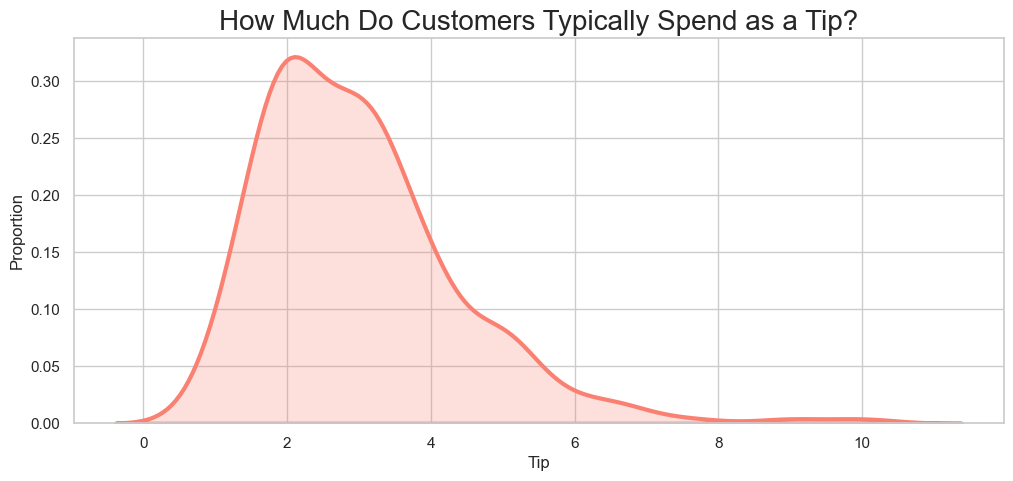

In [85]:
# 13. 'tip' dəyişəninin sıxlıq qrafikini (kdeplot) qurun və sahəsini rənglə doldurun (fill=True).
plt.figure(figsize=(12, 5))
sns.kdeplot(data=df, x="tip", fill=True, color="salmon", lw=3)
plt.title("How Much Do Customers Typically Spend as a Tip?", fontsize=20)
plt.ylabel("Proportion")
plt.xlabel("Tip");

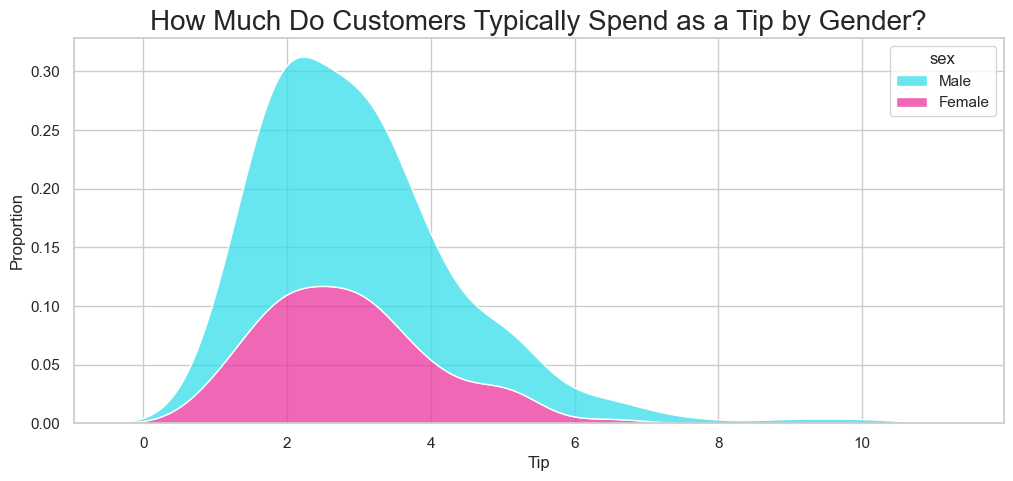

In [86]:
# 14. 'total_bill' sıxlıq qrafikini cinsiyyətə ('sex') görə fərqləndirin (hue) və bir-birinin üzərinə düşməməsi üçün 'multiple="stack"' parametrini sınaqdan keçirin.
plt.figure(figsize=(12, 5))
sns.kdeplot(data=df, x="tip", hue="sex", multiple="stack", fill=True, palette=["#34deeb", "#eb349e"])
plt.title("How Much Do Customers Typically Spend as a Tip by Gender?", fontsize=20)
plt.ylabel("Proportion")
plt.xlabel("Tip");

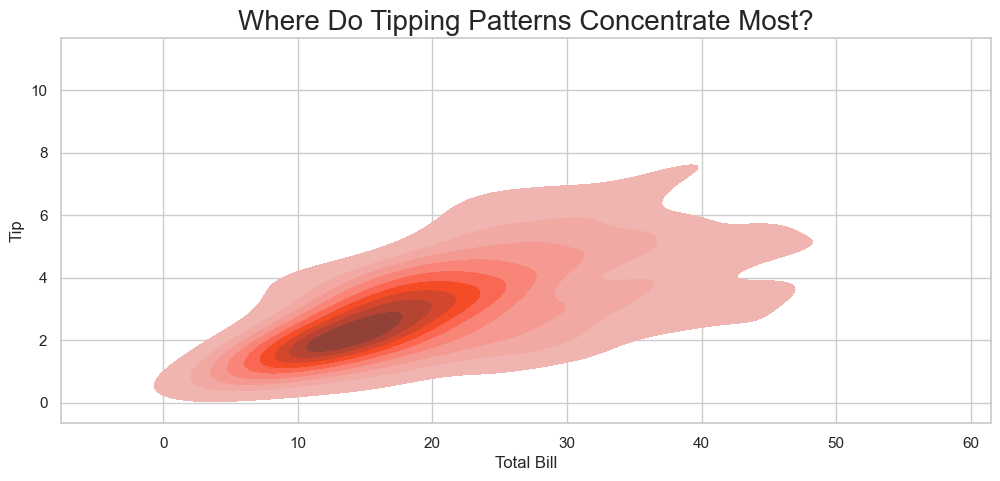

In [94]:
# 15. İki dəyişənli (bivariate) paylanma: 'total_bill' və 'tip' dəyişənlərini eyni 'kdeplot'-a verərək topoqrafik sıxlıq qrafiki yaradın.
plt.figure(figsize=(12, 5))
sns.kdeplot(data=df, x="total_bill", y="tip", fill=True, color="salmon")
plt.title("Where Do Tipping Patterns Concentrate Most?", fontsize=20)
plt.ylabel("Tip")
plt.xlabel("Total Bill");

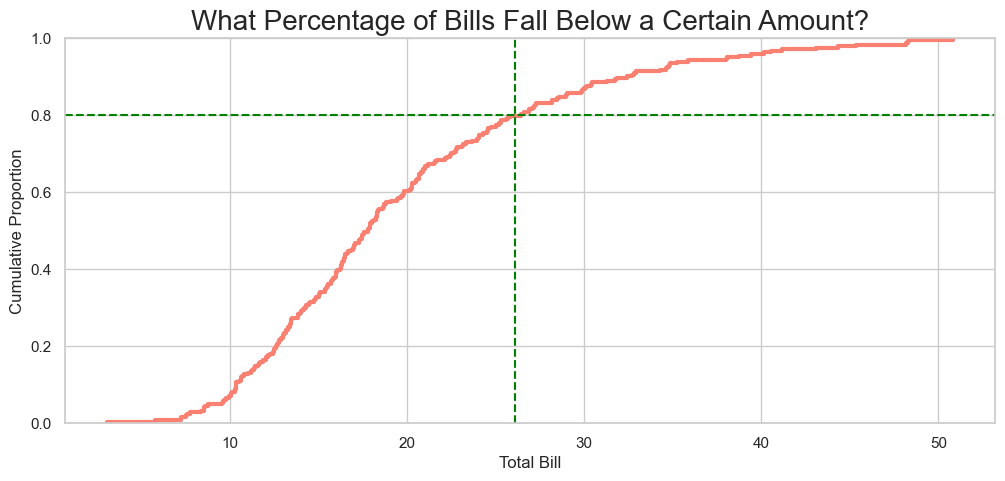

In [105]:
# 16. ECDF (Empirical Cumulative Distribution Function) qrafiki (ecdfplot) vasitəsilə hesabların kumulyativ ehtimalını göstərin.
plt.figure(figsize=(12, 5))
sns.ecdfplot(data=df, x="total_bill", color="salmon", lw=3)
plt.title("What Percentage of Bills Fall Below a Certain Amount?", fontsize=20)
# Creating vertical and horizontal lines in order to visualize what is the pareto about data
total_bill_pareto_value = df["total_bill"].quantile(q=0.8)
plt.axvline(x=total_bill_pareto_value, lw=1.5, ls="dashed", c="green")
plt.axhline(y=0.8, lw=1.5, ls="dashed", c="green")
plt.ylabel("Cumulative Proportion")
plt.xlabel("Total Bill");

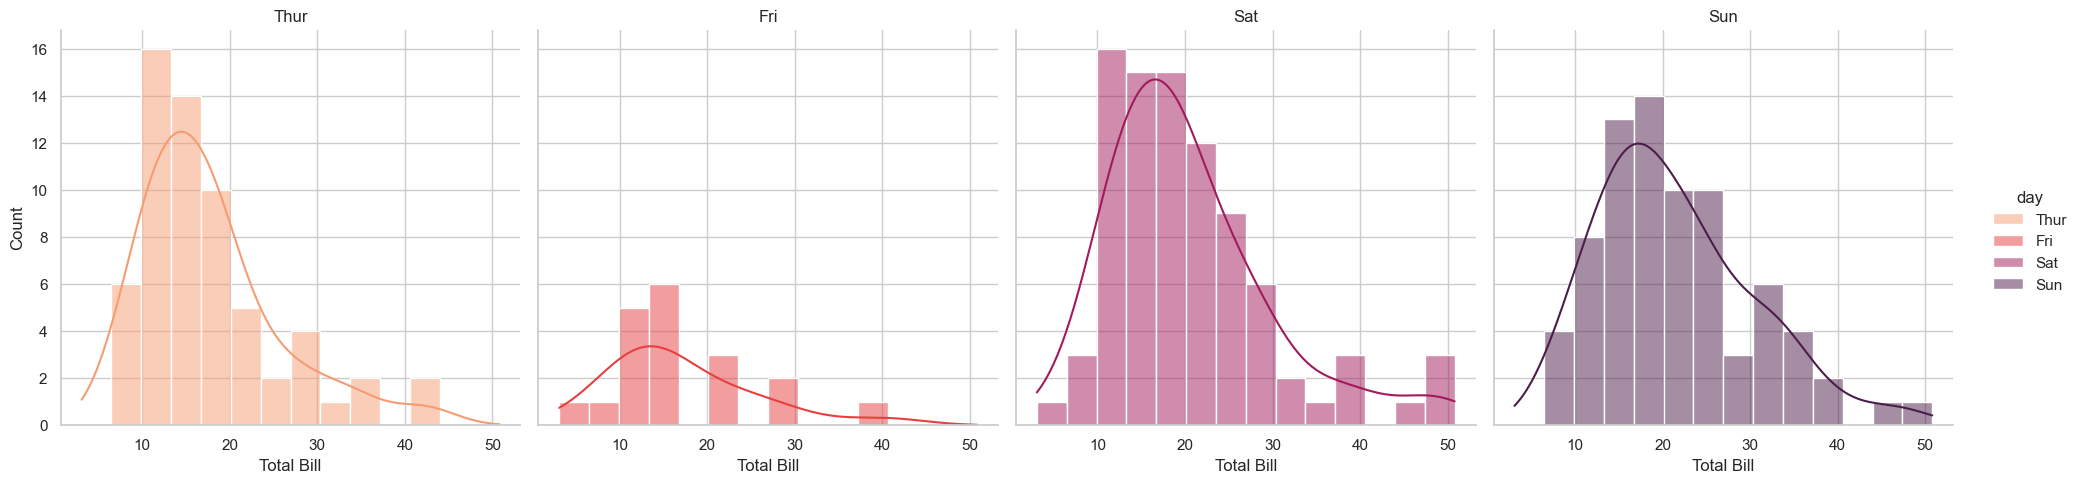

In [112]:
# 17. Ümumi paylanma aləti olan `displot` ilə hesabların paylanmasını günlərə (col='day') görə fərqli panellərdə göstərin.
main = sns.displot(data=df, x="total_bill", col="day", hue="day", palette="rocket_r", kind="hist", kde=True)
main.set_xlabels("Total Bill")
main.set_titles("{col_name}");

### Bölmə 4: Kateqorik qrafiklər (Categorical Plots - barplot, countplot, boxplot, violinplot)

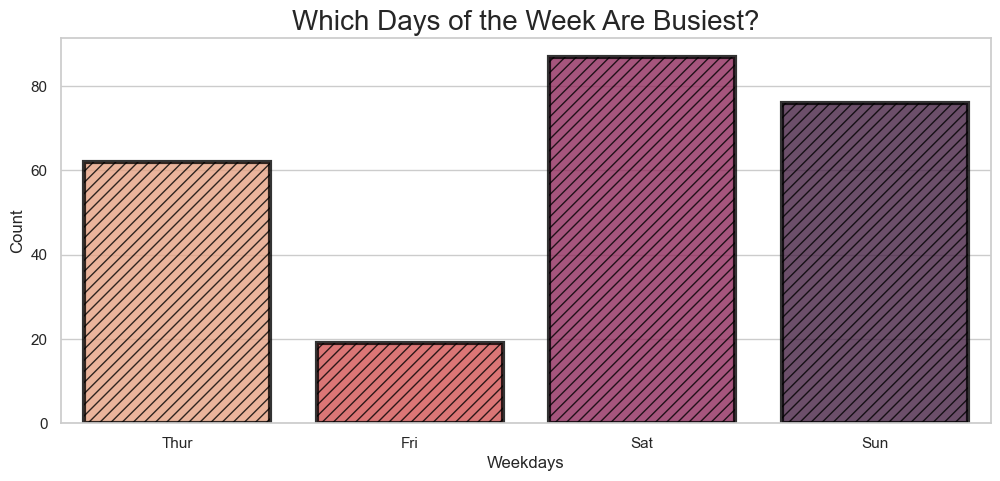

In [139]:
# 18. Həftənin günlərinə ('day') görə cəmi neçə müştərinin gəldiyini göstərən sütunlu qrafik (countplot) qurun.
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x="day", stat="count", hue="day", palette="rocket_r", hatch="///", lw=3, ec="black", alpha=0.8)
plt.title("Which Days of the Week Are Busiest?", fontsize=20)
plt.xlabel("Weekdays")
plt.ylabel("Count");

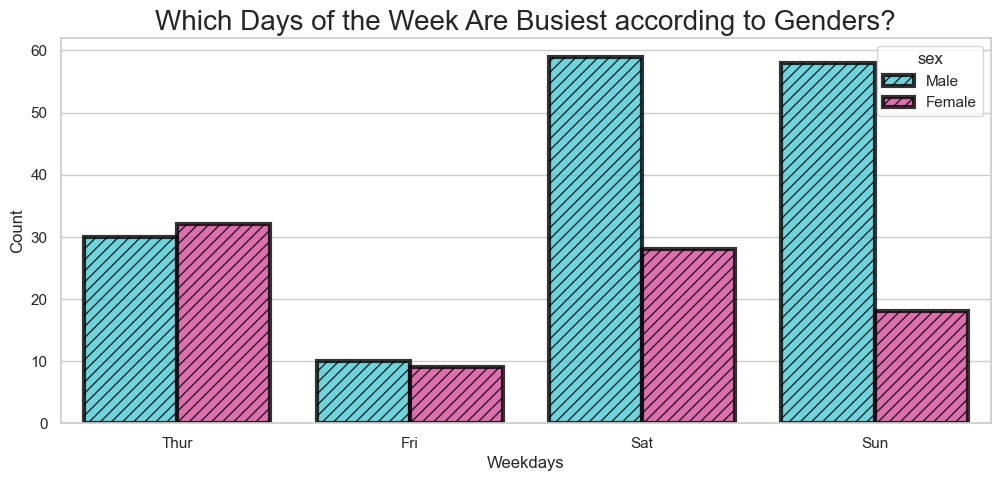

In [142]:
# 19. Günlərə ('day') görə gələn müştərilərin siyahısını cinsiyyətə ('sex') görə alt kateqoriyalara bölün (hue).
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x="day", stat="count", hue="sex", palette=["#34deeb", "#eb349e"], hatch="///", lw=3, ec="black", alpha=0.8)
plt.title("Which Days of the Week Are Busiest according to Genders?", fontsize=20)
plt.xlabel("Weekdays")
plt.ylabel("Count");

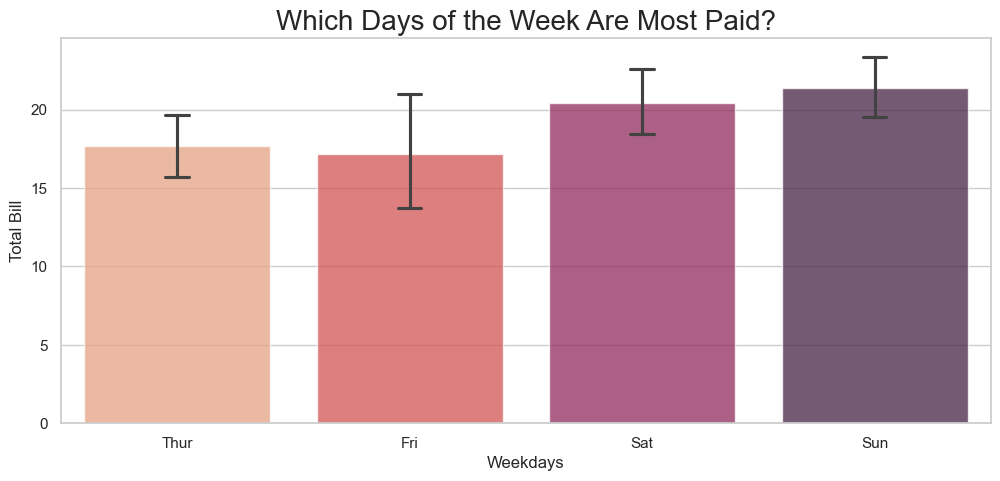

In [372]:
# 20. Hər gün üçün orta hesabı ('total_bill') göstərən qrafik (barplot) qurun. Bu funksiya avtomatik olaraq etibarlılıq intervalını (error bar) göstərəcək.
plt.figure(figsize=(12, 5))
sns.barplot(data=df, y="total_bill", x="day", hue="day", estimator="mean", errorbar=("ci", 95), palette="rocket_r", alpha=0.75, capsize=0.1)
plt.title("Which Days of the Week Are Most Paid?", fontsize=20)
plt.xlabel("Weekdays")
plt.ylabel("Total Bill");

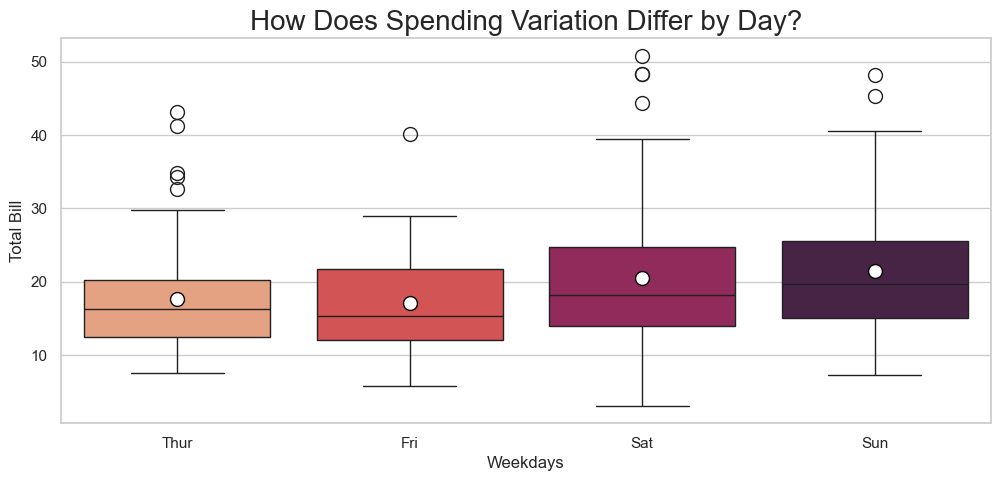

In [367]:
# 21. Günlərə ('day') görə hesabların mərkəzi meylini, kvartilləri və anomaliyaları (outliers) göstərən Qutu qrafiki (boxplot) qurun.
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, y="total_bill", x="day", hue="day", palette="rocket_r", fliersize=10, 
            showmeans=True, meanprops={"marker": "o","markerfacecolor": "white", "markeredgecolor": "black","markersize": "10"})
plt.title("How Does Spending Variation Differ by Day?", fontsize=20)
plt.xlabel("Weekdays")
plt.ylabel("Total Bill");

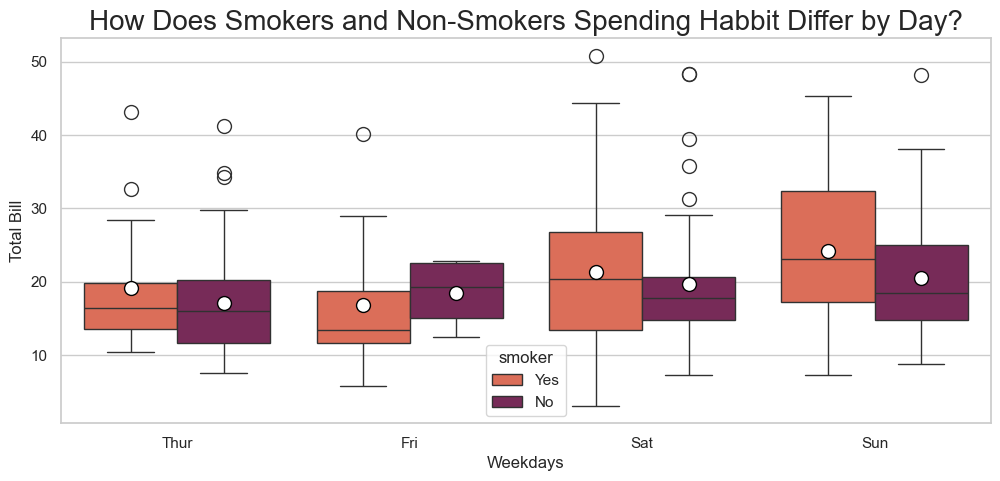

In [213]:
# 22. Əvvəlki Qutu qrafikindəki (boxplot) məlumatları 'smoker' (siqaret çəkən) kateqoriyasına görə yan-yana (hue) fərqləndirin.
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, y="total_bill", x="day", hue="smoker", palette="rocket_r", fliersize=10, 
            showmeans=True, meanprops={"marker": "o","markerfacecolor": "white", "markeredgecolor": "black","markersize": "10"})
plt.title("How Does Smokers and Non-Smokers Spending Habbit Differ by Day?", fontsize=20)
plt.xlabel("Weekdays")
plt.ylabel("Total Bill");

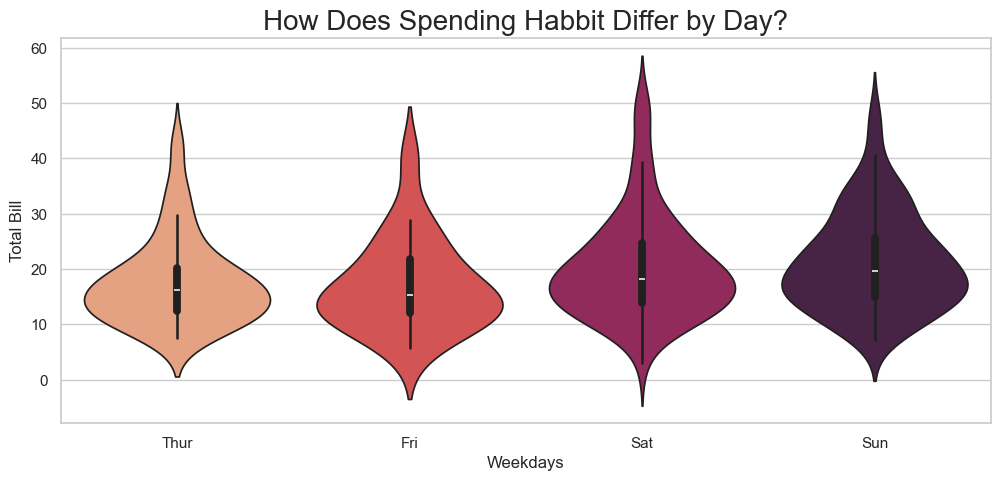

In [182]:
# 23. Məlumatın həm qutu qrafikini, həm də sıxlığını eyni anda göstərən Skripka qrafiki (violinplot) qurun (Y oxu: 'total_bill', X oxu: 'day').
plt.figure(figsize=(12, 5))
sns.violinplot(data=df, x="day", y="total_bill", hue="day", palette="rocket_r")
plt.title("How Does Spending Habbit Differ by Day?", fontsize=20)
plt.xlabel("Weekdays")
plt.ylabel("Total Bill");

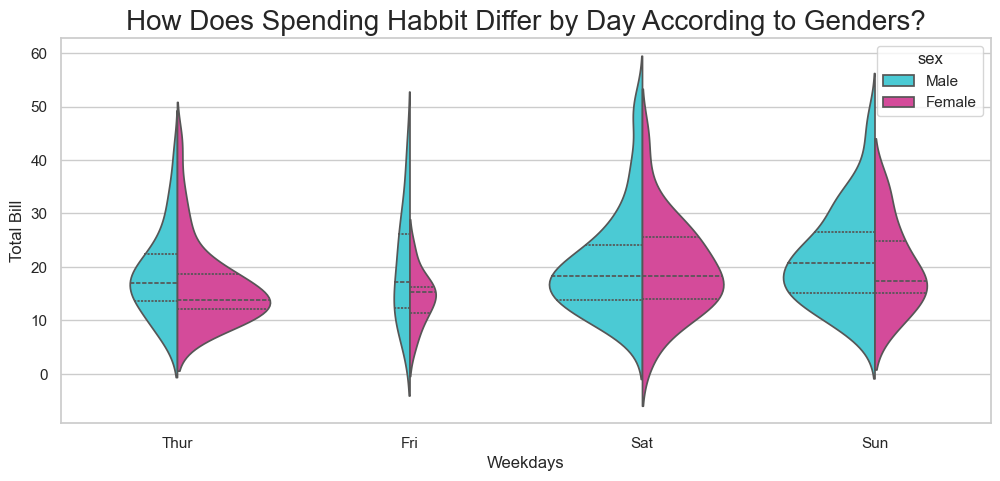

In [187]:
# 24. Skripka qrafikində (violinplot) 'sex' kateqoriyasını 'hue' olaraq verin və hər skripkanın sol və sağ tərəflərini bir kateqoriyaya ayırmaq üçün 'split=True' istifadə edin.
plt.figure(figsize=(12, 5))
sns.violinplot(data=df, x="day", y="total_bill", hue="sex", split=True, palette=["#34deeb", "#eb349e"], inner="quart", density_norm="count")
plt.title("How Does Spending Habbit Differ by Day According to Genders?", fontsize=20)
plt.xlabel("Weekdays")
plt.ylabel("Total Bill");

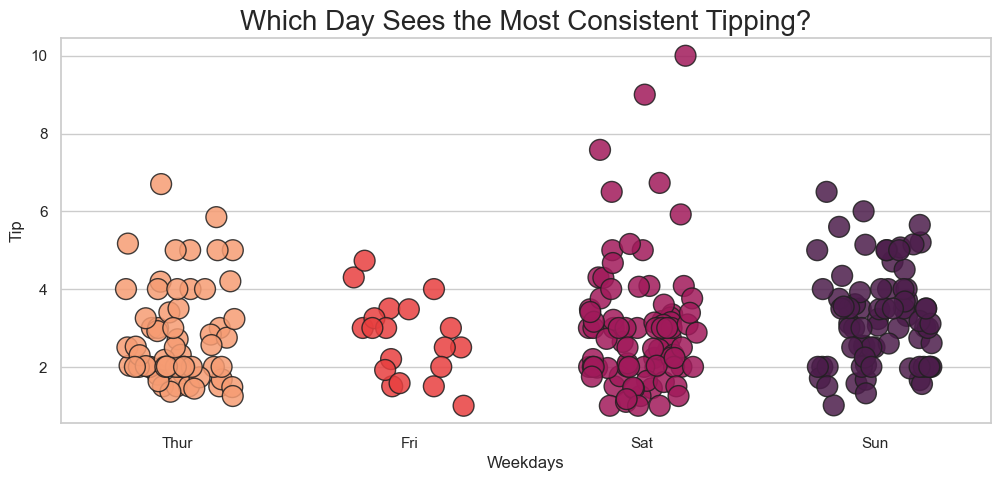

In [203]:
# 25. Kateqorik məlumatların fərdi nöqtələrini göstərən 'stripplot' qurun (X: 'day', Y: 'tip').
plt.figure(figsize=(12, 5))
sns.stripplot(data=df, x="day", y="tip", hue="day", size=15, linewidth=1, palette="rocket_r", alpha=0.85, jitter=0.25)
plt.title("Which Day Sees the Most Consistent Tipping?", fontsize=20)
plt.xlabel("Weekdays")
plt.ylabel("Tip");

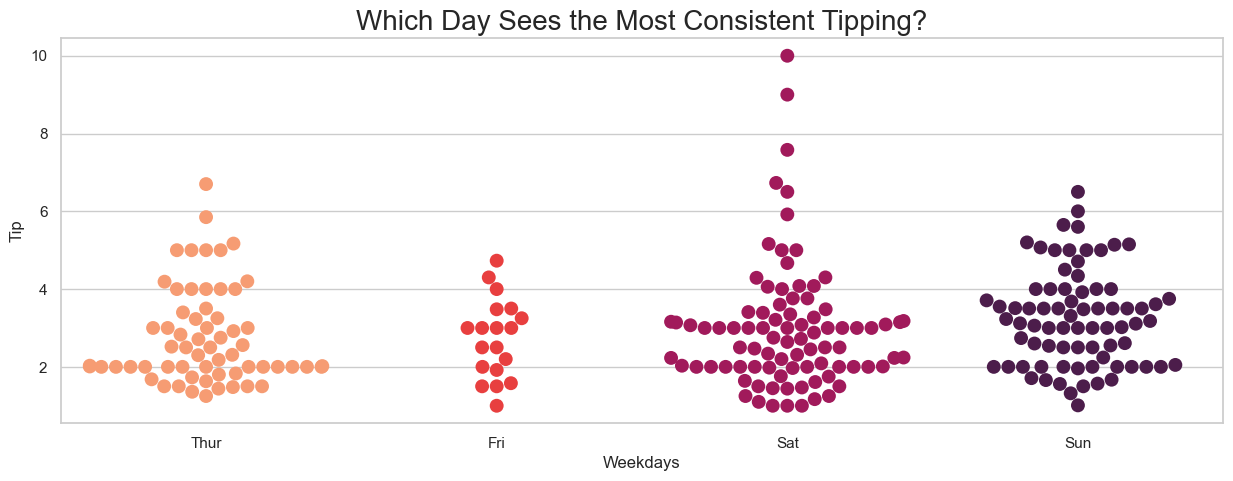

In [212]:
# 26. Nöqtələrin bir-birinin üzərinə düşməsinin (overlap) qarşısını alan və paylanmanı arı pətəyi kimi göstərən 'swarmplot' qurun.
plt.figure(figsize=(15, 5))
sns.swarmplot(data=df, x="day", y="tip", hue="day", palette="rocket_r", size=10)
plt.title("Which Day Sees the Most Consistent Tipping?", fontsize=20)
plt.xlabel("Weekdays")
plt.ylabel("Tip");

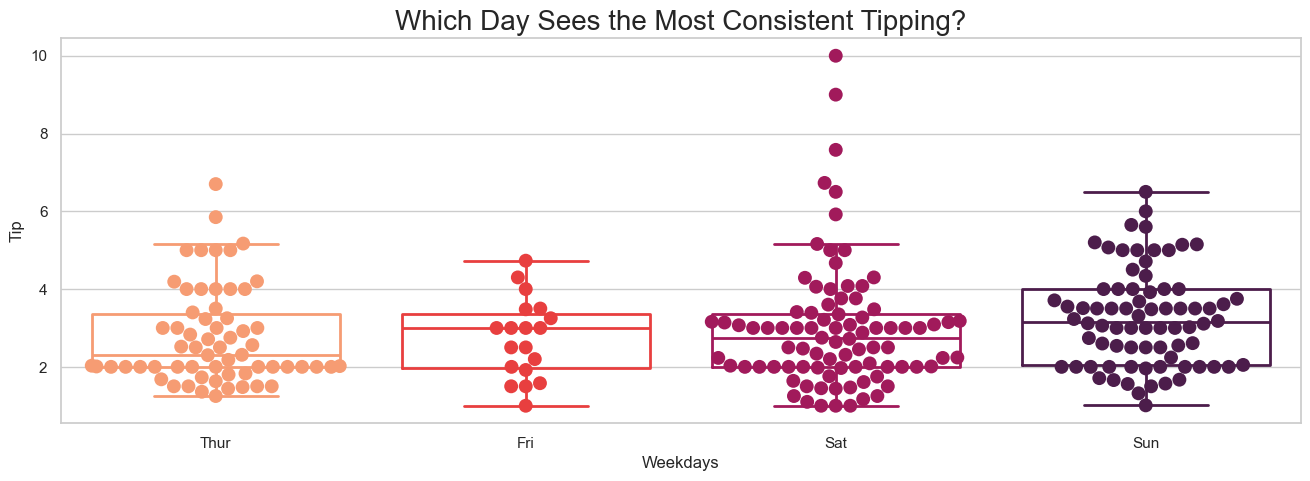

In [230]:
# 27. Mürəkkəb vizual: Eyni qrafik (ax) üzərində əvvəlcə açıq rəngli (color='lightgray') bir boxplot, üzərinə isə swarmplot qurun.
plt.figure(figsize=(16, 5))
sns.boxplot(data=df, y="tip", x="day", hue="day", palette="rocket_r", fliersize=0, fill=False, linewidth=2)
sns.swarmplot(data=df, x="day", y="tip", hue="day", palette="rocket_r", size=10)
plt.title("Which Day Sees the Most Consistent Tipping?", fontsize=20)
plt.xlabel("Weekdays")
plt.ylabel("Tip");

### Bölmə 5: Matris qrafikləri (Matrix Plots - heatmap, clustermap)

In [233]:
# 28. Məlumat dəstindəki yalnız kəmiyyət (numeric) dəyişənləri seçərək Pearson korrelyasiya matrisini (corr) hesablayın və yeni dəyişənə mənimsədin.
df_corr = df.corr(method="pearson", numeric_only=True)
df_corr

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


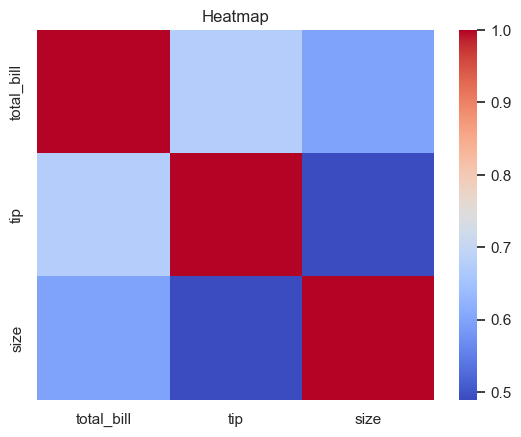

In [352]:
# 29. Yaratdığınız matrisi 'heatmap' vasitəsilə vizuallaşdırın, rəngləri (cmap) 'coolwarm' təyin edin.
sns.heatmap(data=df_corr, cmap="coolwarm")
plt.title("Heatmap");

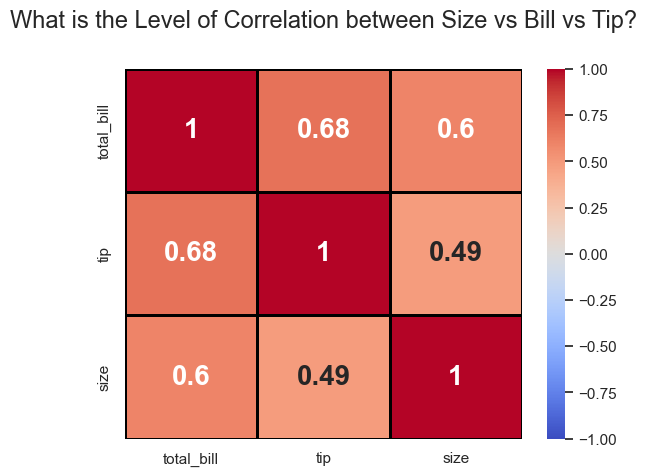

In [365]:
# 30. İstilik xəritəsindəki hər xananın üzərinə korrelyasiya əmsallarını (annot=True) yazdırın.
sns.heatmap(data=df_corr, cmap="coolwarm", annot=True, annot_kws=dict(size=20, weight="bold"), vmin=-1, vmax=1, center=0, linewidths=2, linecolor="black")
plt.title("What is the Level of Correlation between Size vs Bill vs Tip?", fontsize=17, pad=30);

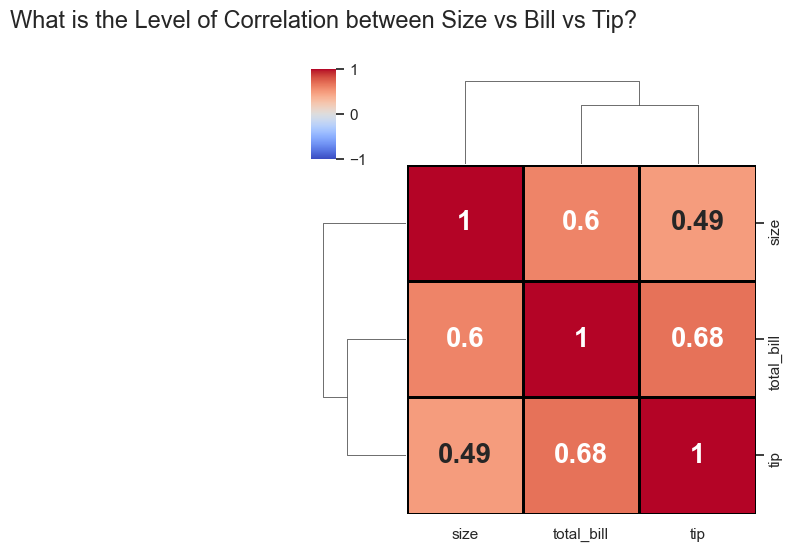

In [362]:
# 31. Dəyişənləri oxşarlığına görə iyerarxik olaraq qruplaşdıran 'clustermap' qurun.
sns.clustermap(data=df_corr, figsize=(5, 5), cmap="coolwarm", vmin=-1, vmax=1, center=0, annot=True, annot_kws=dict(size=20, weight="bold"), linewidths=2, linecolor="black")
plt.title("What is the Level of Correlation between Size vs Bill vs Tip?", fontsize=17, pad=30);

### Bölmə 6: Çoxpanelli şəbəkələr (Multi-plot Grids - pairplot, jointplot)

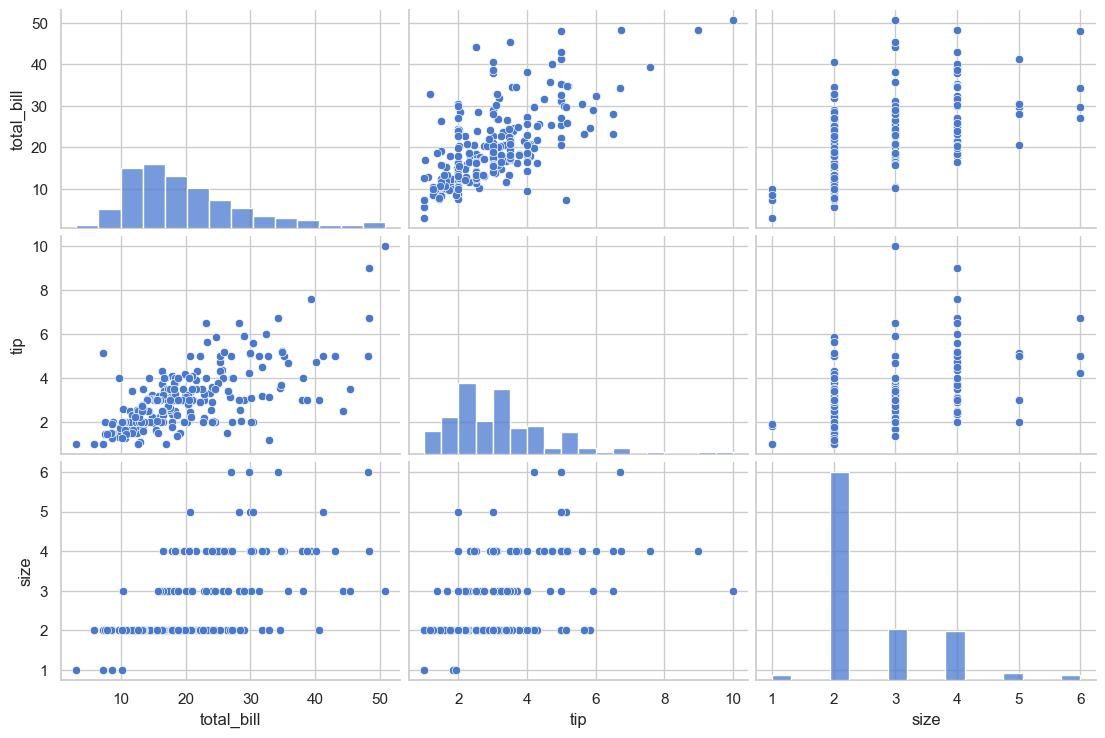

In [276]:
# 32. Məlumat dəstindəki bütün kəmiyyət dəyişənləri arasındakı ikili asılılıqları eyni anda göstərən `pairplot` qurun.
sns.pairplot(data=df, aspect=1.5);

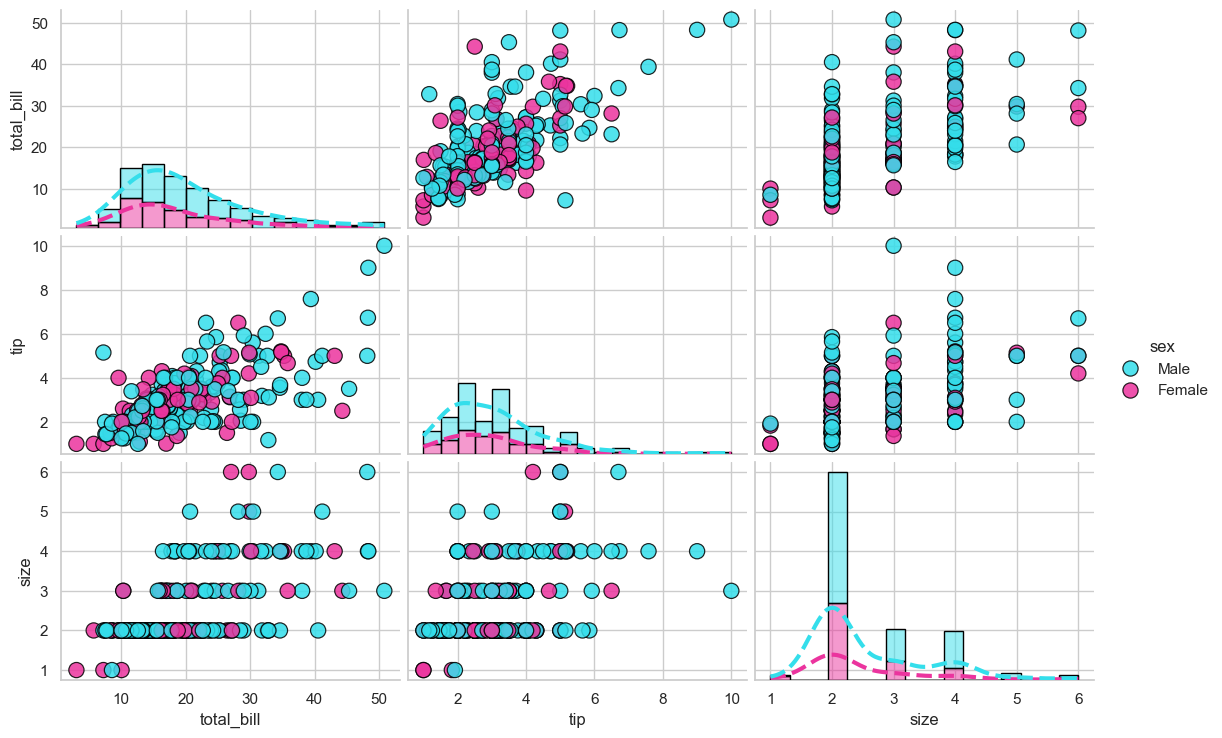

In [304]:
# 33. `pairplot` qrafikindəki bütün asılılıqları cinsiyyətə ('sex') görə rəngləndirin (hue).
sns.pairplot(data=df, aspect=1.5, hue="sex", palette=["#34deeb", "#eb349e"], kind="scatter", diag_kind="hist", 
             plot_kws=dict(s=120, alpha=0.85, ec="black"),
             diag_kws=dict(multiple="stack", kde=True, linewidth=1, edgecolor="black", line_kws=dict(lw=3, ls="dashed")));

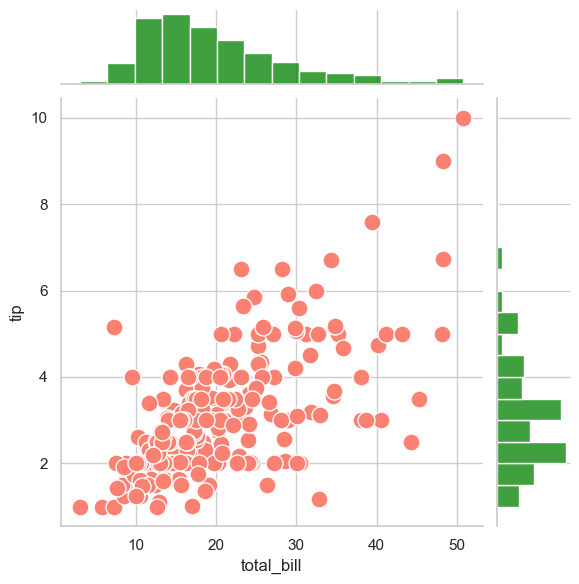

In [324]:
# 34. 'total_bill' və 'tip' dəyişənlərini `jointplot` vasitəsilə birləşdirin (ortada scatter, kənarlarda histogram).
sns.jointplot(data=df, x="total_bill", y="tip", kind="scatter", marginal_kws=dict(color="green"), joint_kws=dict(s=150, color="salmon"));

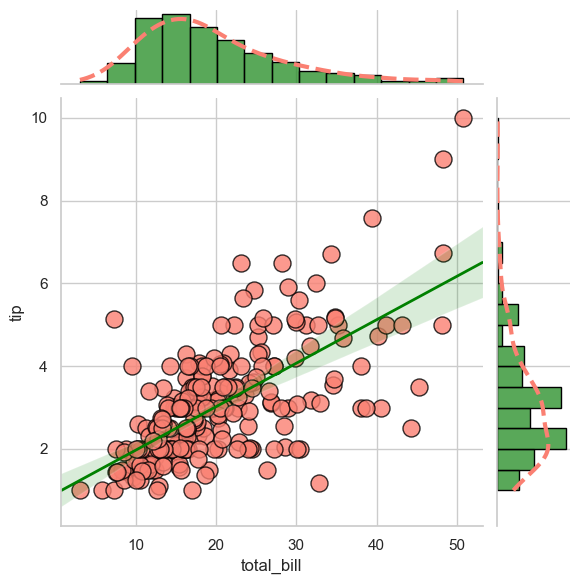

In [339]:
# 35. Əvvəlki `jointplot`-un növünü (kind) reqressiya xətti ('reg') göstərəcək şəkildə dəyişdirin.
sns.jointplot(data=df, x="total_bill", y="tip", kind="reg", 
              marginal_kws=dict(kde=True, color="salmon", line_kws=dict(ls="dashed", lw=3), edgecolor="black", facecolor="#228B22BF"), 
              joint_kws=dict(color="salmon", truncate=False, scatter_kws=dict(s=150, ec="black"), line_kws=dict(lw=2, color="green")));

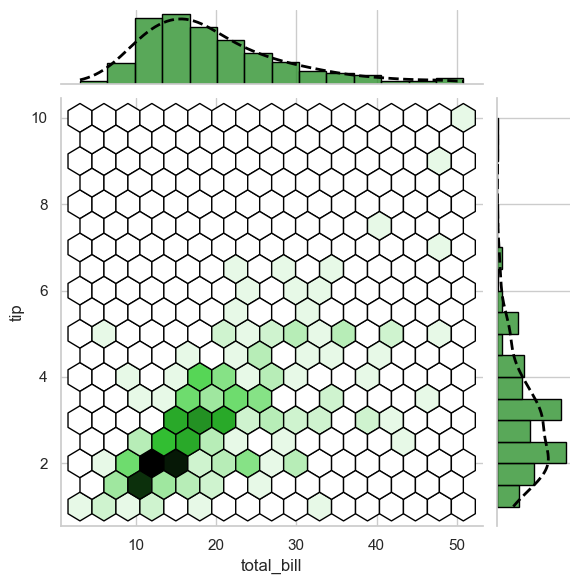

In [375]:
# 36. Sıx məlumat mərkəzlərini altıbucaqlı bal pətəyi şəklində göstərmək üçün `jointplot`-da 'kind="hex"' parametrini istifadə edin.
sns.jointplot(data=df, x="total_bill", y="tip", kind="hex",
              joint_kws=dict(color="black"), color="#228B22BF",
              marginal_kws=dict(kde=True, color="black", line_kws=dict(ls="dashed", lw=2), edgecolor="black", facecolor="#228B22BF"));

### Bölmə 7: Formatlaşdırma və Eksport (Customization & Export)

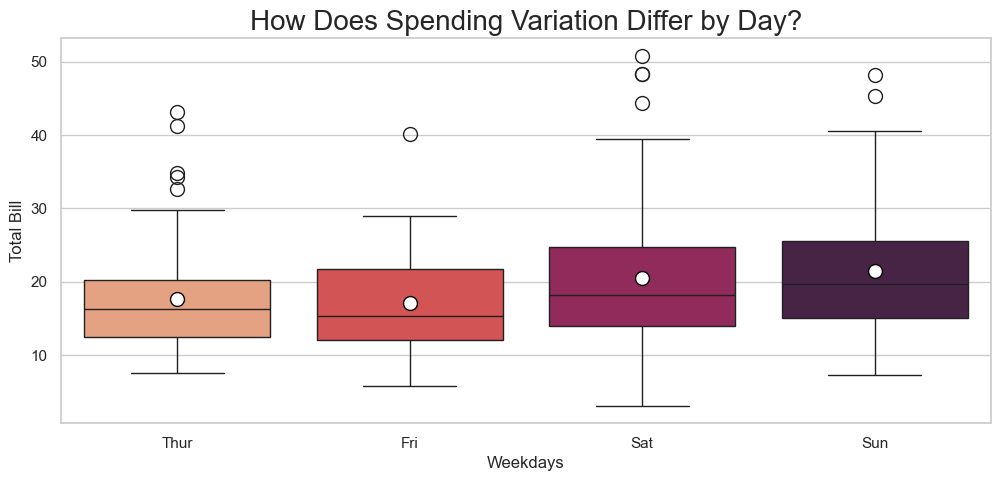

In [368]:
# 37. Hər hansı bir qrafik qurun (məs: boxplot) və Matplotlib obyektindən istifadə edərək ona uyğun akademik Başlıq (title) əlavə edin.
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, y="total_bill", x="day", hue="day", palette="rocket_r", fliersize=10, 
            showmeans=True, meanprops={"marker": "o","markerfacecolor": "white", "markeredgecolor": "black","markersize": "10"})
plt.title("How Does Spending Variation Differ by Day?", fontsize=20)
plt.xlabel("Weekdays")
plt.ylabel("Total Bill");

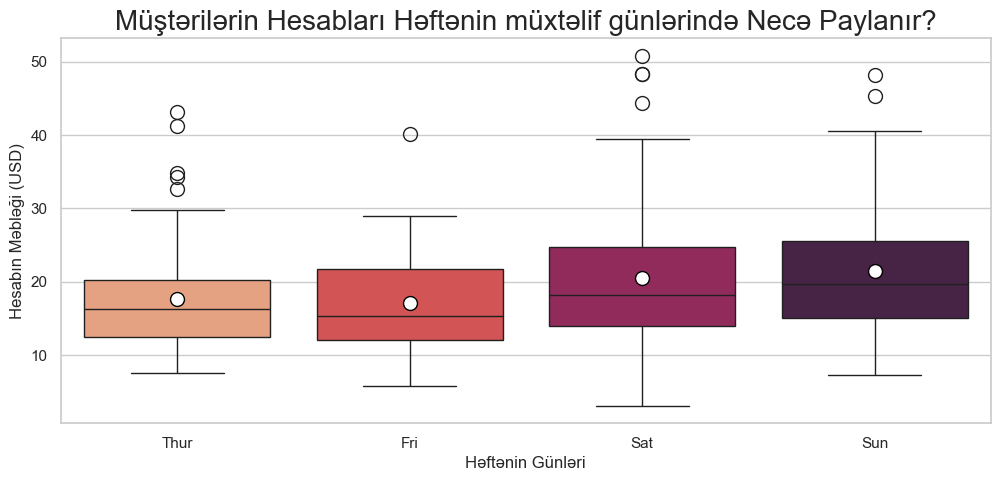

In [371]:
# 38. Əvvəlki qrafikin X və Y oxlarının adlarını (xlabel, ylabel) müvafiq olaraq 'Həftənin Günləri' və 'Hesabın Məbləği (USD)' olaraq dəyişdirin.
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, y="total_bill", x="day", hue="day", palette="rocket_r", fliersize=10, 
            showmeans=True, meanprops={"marker": "o","markerfacecolor": "white", "markeredgecolor": "black","markersize": "10"})
plt.title("Müştərilərin Hesabları Həftənin müxtəlif günlərində Necə Paylanır?", fontsize=20)
plt.xlabel("Həftənin Günləri")
plt.ylabel("Hesabın Məbləği (USD)");

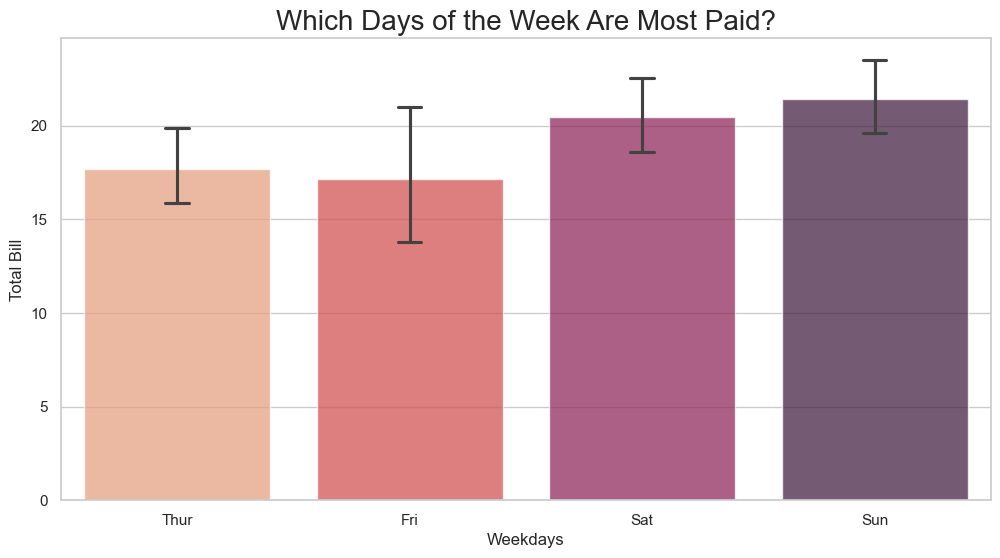

In [373]:
# 39. `plt.figure(figsize=(12, 6))` əmrindən istifadə edərək geniş formatlı bir 'barplot' qurun.
plt.figure(figsize=(12, 6))
sns.barplot(data=df, y="total_bill", x="day", hue="day", estimator="mean", errorbar=("ci", 95), palette="rocket_r", alpha=0.75, capsize=0.1)
plt.title("Which Days of the Week Are Most Paid?", fontsize=20)
plt.xlabel("Weekdays")
plt.ylabel("Total Bill");

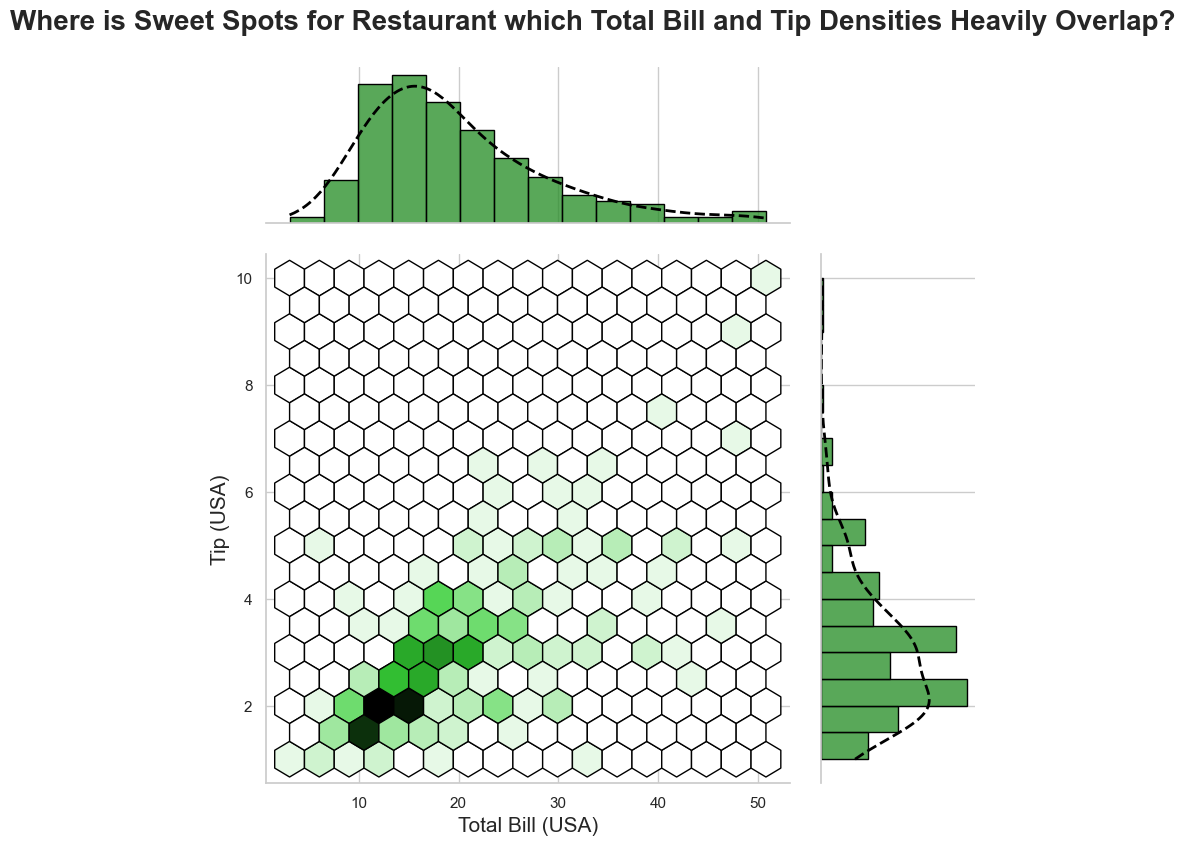

In [395]:
# 40. Qurduğunuz son qrafiki `plt.savefig('seaborn_tapsiriq.png', dpi=300)` vasitəsilə yüksək keyfiyyətlə yaddaşa verin.
main = sns.jointplot(data=df, x="total_bill", y="tip", kind="hex",
              height=8, ratio=3,
              joint_kws=dict(color="black"), color="#228B22BF",
              marginal_kws=dict(kde=True, color="black", line_kws=dict(ls="dashed", lw=2), edgecolor="black", facecolor="#228B22BF"))
main.fig.suptitle("Where is Sweet Spots for Restaurant which Total Bill and Tip Densities Heavily Overlap?", fontsize=20, fontweight='bold', y=1.05)
main.set_axis_labels("Total Bill (USA)", "Tip (USA)", fontsize=15);
plt.savefig("seaborn_task.png", bbox_inches='tight', dpi=300)